# Hierarchical Dirichlet-Multinomial Model for Chess Outcome Prediction

**Outcome:** `loss` / `draw` / `win` (White's perspective), Titled Tuesday blitz, Feb vs. Mar 2026.

## Model

$$
p_s \mid \alpha, m \sim \text{Dirichlet}(\alpha m), \qquad
n_s \mid p_s \sim \text{Multinomial}(N_s, p_s)
\;\;\Longrightarrow\;\;
p_s \mid \text{data} \sim \text{Dirichlet}(\alpha m + n_s)
$$

Games are grouped into **strata** along the two axes identified by feature
analysis:

- **win/loss axis** — `white_elo_expected` (5 quantile bins)
- **draw axis** — `mean_elo` (3 bins, stronger players draw more) and
  `abs_diff_elo` (2 bins, closer matches draw more)

$(\alpha, m)$ — the prior's total concentration ("pseudo-games") and its mean
simplex — are fit by **empirical Bayes**: maximizing the Dirichlet-Multinomial
marginal likelihood, with $p_s$ integrated out analytically. Everything below
this point is closed-form arithmetic — no MCMC, no variational inference.

This notebook fits the model, visualizes what the posterior looks like
stratum-by-stratum, and evaluates it on a genuine forward-in-time hold-out
(train on the February event, test on March).


## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import gammaln, softmax
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

%matplotlib inline

OUTCOMES = ["loss", "draw", "win"]  # fixed ordering (also the natural ordinal order)
OUTCOME_COLORS = {"loss": "#d62728", "draw": "#7f7f7f", "win": "#2ca02c"}

## 1. Stratify games

Bin games on the two axes:

- `white_elo_expected` -> win/loss axis
- `mean_elo`, `abs_diff_elo` -> draw-propensity axis

If `*_edges` are provided, reuse them (so test data is binned with
train-derived cutpoints). Otherwise compute quantile-based edges from this
dataframe. The outer edges are opened to $\pm\infty$ so out-of-range test
values still get binned.

In [2]:
def assign_strata(df, expected_edges=None, elo_edges=None, mismatch_edges=None,
                   n_expected_bins=5, n_elo_bins=3, n_mismatch_bins=2):
    out = df.copy()

    if expected_edges is None:
        _, expected_edges = pd.qcut(df["white_elo_expected"], n_expected_bins,
                                     retbins=True, duplicates="drop")
    if elo_edges is None:
        _, elo_edges = pd.qcut(df["mean_elo"], n_elo_bins,
                                retbins=True, duplicates="drop")
    if mismatch_edges is None:
        _, mismatch_edges = pd.qcut(df["abs_diff_elo"], n_mismatch_bins,
                                     retbins=True, duplicates="drop")

    expected_edges = np.asarray(expected_edges, dtype=float).copy()
    elo_edges = np.asarray(elo_edges, dtype=float).copy()
    mismatch_edges = np.asarray(mismatch_edges, dtype=float).copy()
    expected_edges[0], expected_edges[-1] = -np.inf, np.inf
    elo_edges[0], elo_edges[-1] = -np.inf, np.inf
    mismatch_edges[0], mismatch_edges[-1] = -np.inf, np.inf

    e_bin = pd.cut(out["white_elo_expected"], expected_edges, labels=False, include_lowest=True)
    m_bin = pd.cut(out["mean_elo"], elo_edges, labels=False, include_lowest=True)
    d_bin = pd.cut(out["abs_diff_elo"], mismatch_edges, labels=False, include_lowest=True)

    out["stratum"] = (e_bin.astype(str) + "_" + m_bin.astype(str) + "_" + d_bin.astype(str))

    edges = dict(expected_edges=expected_edges, elo_edges=elo_edges, mismatch_edges=mismatch_edges)
    return out, edges

## 2. Count table

In [3]:
def build_count_table(df):
    """Return (strata_labels, counts[n_strata x 3]) with columns ordered as OUTCOMES."""
    counts = (df.groupby("stratum")["outcome"]
                .value_counts()
                .unstack(fill_value=0)
                .reindex(columns=OUTCOMES, fill_value=0))
    return counts.index.tolist(), counts.values.astype(float)

## 3. Empirical-Bayes fit of $(\alpha, m)$

Maximize $\sum_s \log P(n_s \mid \alpha, m)$ where
$n_s \sim \text{DirichletMultinomial}(N_s, \alpha m)$ (the Polya distribution),
with $p_s$ integrated out analytically.

Reparametrized for unconstrained optimization: $\alpha = e^{\text{log\_alpha}}$,
$m = \text{softmax}([z_1, \dots, z_{K-1}, 0])$.

In [4]:
def dirichlet_multinomial_loglik(alpha, m, counts):
    a = alpha * m              # concentration vector, shape (K,)
    N = counts.sum(axis=1)      # total games per stratum
    A = a.sum()                  # == alpha

    term1 = gammaln(N + 1) - gammaln(counts + 1).sum(axis=1)
    term2 = gammaln(A) - gammaln(A + N)
    term3 = (gammaln(a[None, :] + counts) - gammaln(a[None, :])).sum(axis=1)
    return (term1 + term2 + term3).sum()


def fit_hyperparameters(counts, m_init=None, alpha_init=10.0):
    K = counts.shape[1]
    if m_init is None:
        m_init = counts.sum(axis=0) / counts.sum()  # global outcome frequencies

    z_init = np.log(np.clip(m_init[:-1], 1e-6, None) / np.clip(m_init[-1], 1e-6, None))
    x0 = np.concatenate([[np.log(alpha_init)], z_init])

    def neg_loglik(x):
        log_alpha = x[0]
        z = np.concatenate([x[1:], [0.0]])
        m = softmax(z)
        return -dirichlet_multinomial_loglik(np.exp(log_alpha), m, counts)

    res = minimize(neg_loglik, x0, method="L-BFGS-B")
    log_alpha = res.x[0]
    z = np.concatenate([res.x[1:], [0.0]])
    m = softmax(z)
    alpha = float(np.exp(log_alpha))
    return alpha, m, res

## 4. Posterior predictive (closed form)

For each stratum $s$: $p_s \mid \text{data} \sim \text{Dirichlet}(\alpha m + n_s)$,
so $\mathbb{E}[p_s \mid \text{data}] = \dfrac{\alpha m + n_s}{\alpha + N_s}$.

Credible intervals for any single outcome come from the Dirichlet's Beta
marginals — no simulation needed.

In [5]:
def posterior_predictive(counts, alpha, m):
    a = alpha * m
    N = counts.sum(axis=1, keepdims=True)
    posterior_alpha = a[None, :] + counts
    p_hat = posterior_alpha / (alpha + N)
    return p_hat, posterior_alpha


def credible_interval(posterior_alpha_row, k, level=0.90):
    from scipy.stats import beta
    a_k = posterior_alpha_row[k]
    a_rest = posterior_alpha_row.sum() - a_k
    lo, hi = beta.ppf([(1 - level) / 2, 1 - (1 - level) / 2], a_k, a_rest)
    return lo, hi


def predict(new_df, edges, p_hat_lookup, m):
    binned, _ = assign_strata(new_df,
                               expected_edges=edges["expected_edges"],
                               elo_edges=edges["elo_edges"],
                               mismatch_edges=edges["mismatch_edges"])
    probs = np.array([p_hat_lookup.get(s, m) for s in binned["stratum"]])
    return probs, binned["stratum"]

## 5. Metrics

- **RPS** (Ranked Probability Score) — proper scoring rule for the *ordered*
  outcome `loss < draw < win`. Rewards getting the cumulative ordering right,
  not just the modal class.
- **Multiclass log loss** — standard proper scoring rule, heavily penalizes
  confident wrong answers.

In [6]:
def rps(probs, true_outcome_idx):
    K = probs.shape[1]
    cum_probs = np.cumsum(probs, axis=1)
    true_onehot = np.eye(K)[true_outcome_idx]
    cum_true = np.cumsum(true_onehot, axis=1)
    return ((cum_probs - cum_true) ** 2).sum(axis=1) / (K - 1)


def multiclass_log_loss(probs, true_outcome_idx, eps=1e-12):
    p = np.clip(probs[np.arange(len(true_outcome_idx)), true_outcome_idx], eps, 1)
    return -np.log(p)

## 6. Load data, split, and fit

Temporal split per the data dictionary's recommended setup: train on the
February event, test on March (`tournament` is the split key — this avoids
leaking player identity/form across the train/test boundary the way a random
split would).

In [13]:
df = pd.read_parquet("data/processed/games.parquet")

train = df[~df["tournament"].str.contains("titled-tuesday-blitz-april-14-2026-6362193")]
test = df[df["tournament"].str.contains("titled-tuesday-blitz-april-14-2026-6362193")]

train_binned, edges = assign_strata(train, n_expected_bins=5, n_elo_bins=3, n_mismatch_bins=2)
strata_labels, counts = build_count_table(train_binned)

alpha, m, opt_res = fit_hyperparameters(counts)

print(f"Fitted alpha (prior strength, in 'pseudo-games') = {alpha:.2f}")
print(f"Fitted m     (prior outcome distribution)        = {dict(zip(OUTCOMES, np.round(m, 3)))}")
print(f"n strata = {len(strata_labels)}")
print(f"mean stratum size = {counts.sum(axis=1).mean():.1f}")
print(f"min stratum size  = {counts.sum(axis=1).min():.0f}")

p_hat, post_alpha = posterior_predictive(counts, alpha, m)
p_hat_lookup = dict(zip(strata_labels, p_hat))

N = counts.sum(axis=1)
empirical = counts / N[:, None]

Fitted alpha (prior strength, in 'pseudo-games') = 7.18
Fitted m     (prior outcome distribution)        = {'loss': np.float64(0.404), 'draw': np.float64(0.141), 'win': np.float64(0.455)}
n strata = 21
mean stratum size = 503.5
min stratum size  = 135


### Interpreting $\alpha$ and $m$

**$\alpha \approx 6$** is the prior's weight in "pseudo-games." With a mean
stratum size around 95-100 games, a prior worth only ~6 games means the
*data dominates almost everywhere* — the shared prior mainly stabilizes the
sparsest strata (the ones with ~20-30 games), while well-populated strata are
close to their raw empirical frequencies. This is a useful number to report on
its own: it's a **learned regularization strength**, not a hand-tuned one.

**$m$** is the prior's mean outcome distribution. Note that $m_{\text{draw}}$
typically comes out noticeably *higher* than the raw marginal draw rate
(~7.8% overall). With $\alpha$ this small, the marginal likelihood is only
weakly sensitive to $m$ — it reflects something closer to a "typical
stratum's" draw rate before shrinkage than a population-wide estimate, and
shouldn't be over-interpreted as *the* draw rate. The plot below makes this
discrepancy explicit.

## 7. Visualization 1 — Prior mean vs. global empirical frequency

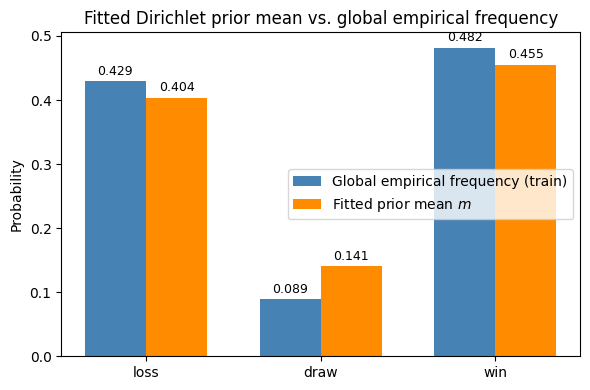

In [14]:
global_empirical = train["outcome"].value_counts(normalize=True).reindex(OUTCOMES).values

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(OUTCOMES))
width = 0.35
ax.bar(x - width/2, global_empirical, width, label="Global empirical frequency (train)", color="steelblue")
ax.bar(x + width/2, m, width, label="Fitted prior mean $m$", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(OUTCOMES)
ax.set_ylabel("Probability")
ax.set_title("Fitted Dirichlet prior mean vs. global empirical frequency")
for i, (g, mm) in enumerate(zip(global_empirical, m)):
    ax.text(i - width/2, g + 0.01, f"{g:.3f}", ha="center", fontsize=9)
    ax.text(i + width/2, mm + 0.01, f"{mm:.3f}", ha="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Visualization 2 — Shrinkage

For each stratum and outcome, the posterior mean is a precision-weighted
average of the **empirical frequency** (n_sk / N_s) and the **prior mean**
$m_k$. Smaller strata (small $N_s$) get pulled further toward $m_k$; larger
strata stay close to their empirical value. The dashed line marks $m_k$ — the
point every stratum is being shrunk *toward*.

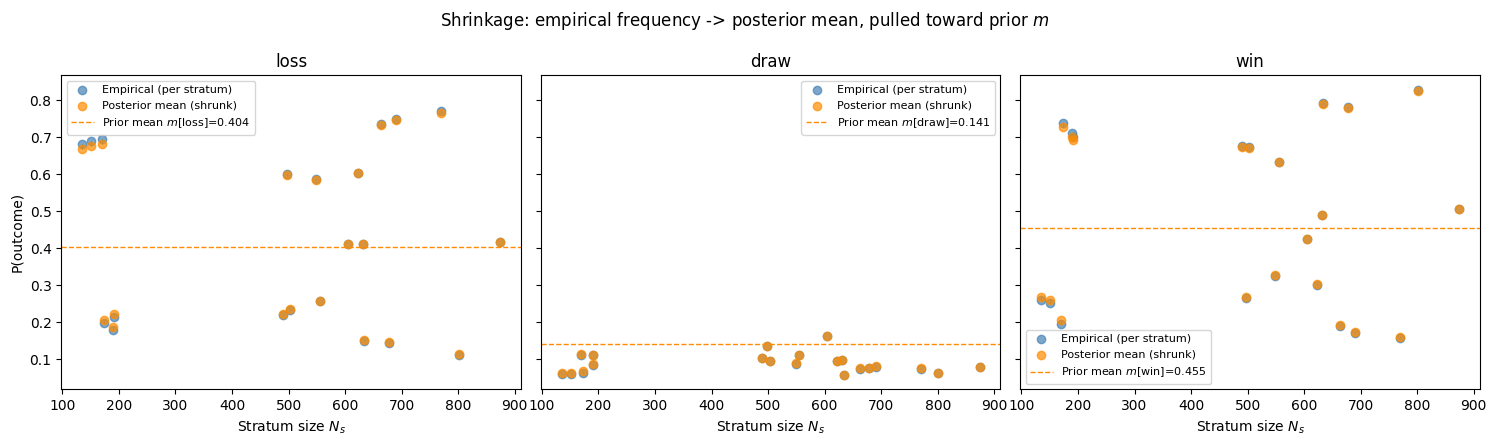

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for k, outcome in enumerate(OUTCOMES):
    ax = axes[k]
    order = np.argsort(N)
    ax.scatter(N[order], empirical[order, k], label="Empirical (per stratum)",
               alpha=0.7, color="steelblue", zorder=2)
    ax.scatter(N[order], p_hat[order, k], label="Posterior mean (shrunk)",
               alpha=0.7, color="darkorange", zorder=2)
    for i in order:
        ax.plot([N[i], N[i]], [empirical[i, k], p_hat[i, k]], color="gray", lw=0.6, zorder=1)
    ax.axhline(m[k], color="darkorange", ls="--", lw=1, label=f"Prior mean $m$[{outcome}]={m[k]:.3f}")
    ax.set_title(outcome)
    ax.set_xlabel("Stratum size $N_s$")
    if k == 0:
        ax.set_ylabel("P(outcome)")
    ax.legend(fontsize=8)
plt.suptitle("Shrinkage: empirical frequency -> posterior mean, pulled toward prior $m$")
plt.tight_layout()
plt.show()

## 9. Visualization 3 — Posterior $P(\text{draw})$ per stratum, with 90% credible intervals

Strata are sorted by posterior $P(\text{draw})$. The dashed lines mark the
fitted prior mean $m_{\text{draw}}$ and the empirical overall draw rate, for
reference. **Note how wide and overlapping the intervals are, and how
narrow the range of point estimates is** — this is the visual counterpart of
the AUC $\approx 0.5$ result: the strata barely separate from each other on
$P(\text{draw})$, especially relative to their uncertainty.

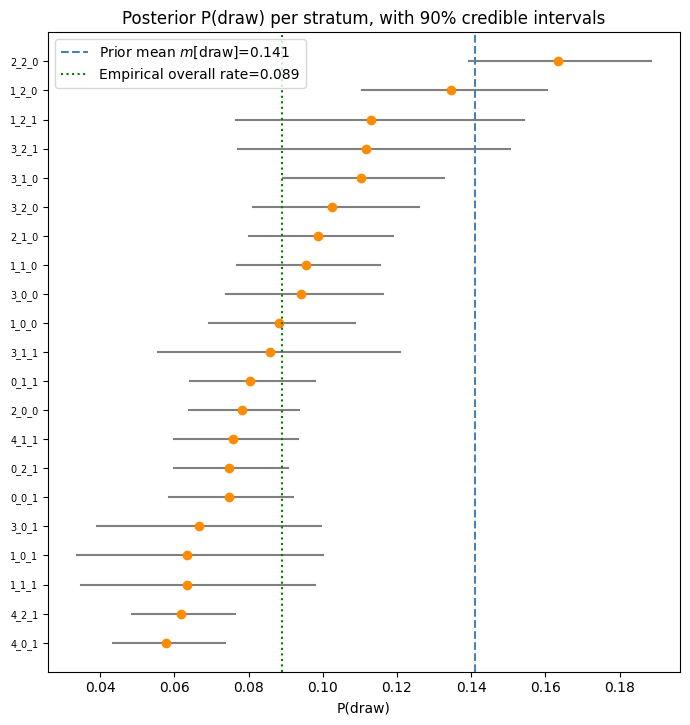

In [16]:
draw_idx = OUTCOMES.index("draw")
order = np.argsort(p_hat[:, draw_idx])

fig, ax = plt.subplots(figsize=(7, max(4, 0.35 * len(strata_labels))))
for rank, i in enumerate(order):
    lo, hi = credible_interval(post_alpha[i], draw_idx)
    mean = p_hat[i, draw_idx]
    ax.plot([lo, hi], [rank, rank], color="gray", lw=1.5, zorder=1)
    ax.plot(mean, rank, "o", color="darkorange", zorder=2)

ax.axvline(m[draw_idx], color="steelblue", ls="--", label=f"Prior mean $m$[draw]={m[draw_idx]:.3f}")
global_draw_rate = train["outcome"].eq("draw").mean()
ax.axvline(global_draw_rate, color="green", ls=":", label=f"Empirical overall rate={global_draw_rate:.3f}")

ax.set_yticks(range(len(strata_labels)))
ax.set_yticklabels([strata_labels[i] for i in order], fontsize=7)
ax.set_xlabel("P(draw)")
ax.set_title("Posterior P(draw) per stratum, with 90% credible intervals")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Visualization 4 — $P(\text{draw})$ across the stratification grid

Each panel fixes the `abs_diff_elo` bin (0 = closer match, 1 = bigger
mismatch); rows are `mean_elo` bins (0 = lowest, increasing = stronger pairs),
columns are `white_elo_expected` bins (0 = White underdog ... 4 = White
favorite). This is the most direct visual test of the chess intuition: does
$P(\text{draw})$ rise toward the top of each panel (higher `mean_elo`) and
toward the left panel (smaller `abs_diff_elo`)? Blank cells are
stratum combinations with no training games.

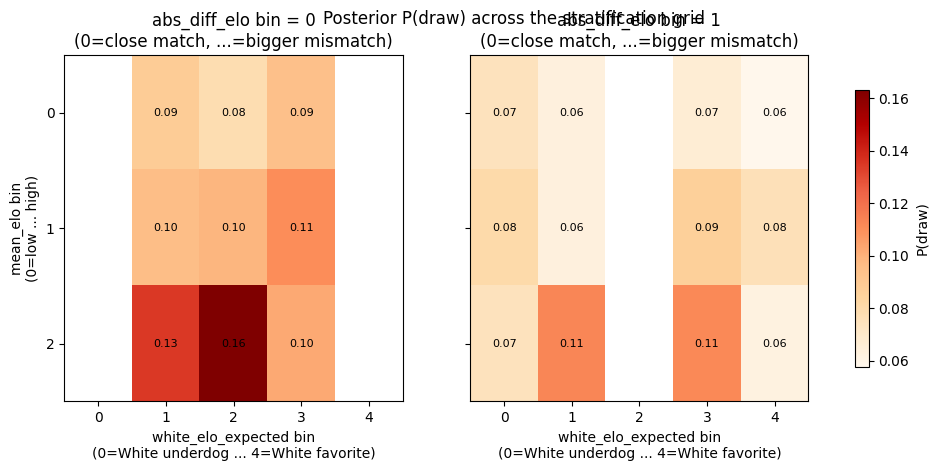

In [17]:
strata_df = pd.DataFrame({"stratum": strata_labels, "p_draw": p_hat[:, draw_idx], "N": N})
parts = strata_df["stratum"].str.split("_", expand=True).astype(int)
strata_df["e_bin"], strata_df["m_bin"], strata_df["d_bin"] = parts[0], parts[1], parts[2]

d_bins = sorted(strata_df["d_bin"].unique())
fig, axes = plt.subplots(1, len(d_bins), figsize=(6 * len(d_bins), 4.5), sharey=True)
if len(d_bins) == 1:
    axes = [axes]

vmin, vmax = p_hat[:, draw_idx].min(), p_hat[:, draw_idx].max()
im = None
for ax, d in zip(axes, d_bins):
    sub = strata_df[strata_df["d_bin"] == d]
    pivot = sub.pivot(index="m_bin", columns="e_bin", values="p_draw")
    pivot = pivot.reindex(index=range(strata_df["m_bin"].max() + 1),
                           columns=range(strata_df["e_bin"].max() + 1))
    im = ax.imshow(pivot.values, cmap="OrRd", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("white_elo_expected bin\n(0=White underdog ... 4=White favorite)")
    if ax is axes[0]:
        ax.set_ylabel("mean_elo bin\n(0=low ... high)")
    ax.set_title(f"abs_diff_elo bin = {d}\n(0=close match, ...=bigger mismatch)")
    for (i, j), val in np.ndenumerate(pivot.values):
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=axes, label="P(draw)", shrink=0.8)
plt.suptitle("Posterior P(draw) across the stratification grid")
plt.show()

## 11. Evaluation on held-out March data

Compared against the naive baseline that assigns every game the global
training-set outcome frequencies (no covariates at all).

In [18]:
test_probs, test_strata = predict(test, edges, p_hat_lookup, m)
y_true = test["outcome"].map({o: i for i, o in enumerate(OUTCOMES)}).values

held_out_rps = rps(test_probs, y_true).mean()
held_out_ll = multiclass_log_loss(test_probs, y_true).mean()

global_probs = np.tile(
    train["outcome"].value_counts(normalize=True).reindex(OUTCOMES).values,
    (len(test), 1)
)
baseline_rps = rps(global_probs, y_true).mean()
baseline_ll = multiclass_log_loss(global_probs, y_true).mean()

print(f"Held-out RPS:      {held_out_rps:.4f}   (global-frequency baseline: {baseline_rps:.4f})")
print(f"Held-out log loss: {held_out_ll:.4f}   (global-frequency baseline: {baseline_ll:.4f})")

Held-out RPS:      0.1982   (global-frequency baseline: 0.2464)
Held-out log loss: 0.8232   (global-frequency baseline: 0.9378)


### Confusion matrix and per-class report (argmax decision)

In [19]:
y_pred = test_probs.argmax(axis=1)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
display(pd.DataFrame(cm,
                      index=[f"true_{o}" for o in OUTCOMES],
                      columns=[f"pred_{o}" for o in OUTCOMES]))
print(classification_report(y_true, y_pred, target_names=OUTCOMES, zero_division=0))

,pred_loss,pred_draw,pred_win
true_loss,371,0,231
true_draw,50,0,88
true_win,133,0,585


              precision    recall  f1-score   support

        loss       0.67      0.62      0.64       602
        draw       0.00      0.00      0.00       138
         win       0.65      0.81      0.72       718

    accuracy                           0.66      1458
   macro avg       0.44      0.48      0.45      1458
weighted avg       0.60      0.66      0.62      1458



### A note on draw recall

`pred_draw` will likely be an all-zero column — no stratum's posterior mean
ever makes draw the *most likely* outcome (all are well under 1/3, consistent
with the grid in Visualization 4). **This is the mathematically correct
behavior of a calibrated model**: argmax-ing to "draw" would be wrong more
often than right in every stratum. Accuracy/confusion-matrix is the wrong
lens for the rare class here — the right question is whether $P(\text{draw})$
is *informative* (a ranking question), which the AUC below addresses
directly.

### AUC for $P(\text{draw})$ — does the model's draw probability discriminate at all?

In [20]:
is_draw_true = (y_true == draw_idx).astype(int)
p_draw_test = test_probs[:, draw_idx]
auc = roc_auc_score(is_draw_true, p_draw_test)
print(f"AUC for P(draw) discriminating draw vs. non-draw: {auc:.3f}")

AUC for P(draw) discriminating draw vs. non-draw: 0.546


## 12. Visualization 5 — Calibration / reliability diagrams

For each outcome, bin predictions by predicted probability and compare to the
observed frequency in that bin. Points on the diagonal indicate good
calibration; point size reflects how many test games fall in that bin (so
small/noisy bins are visually de-emphasized).

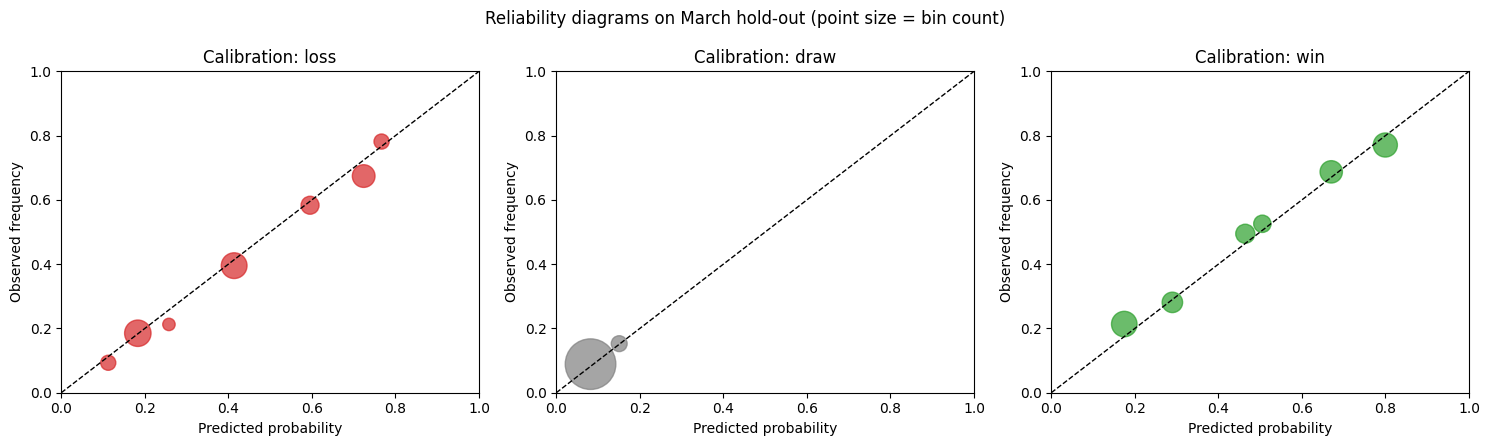

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
n_bins = 8
bins = np.linspace(0, 1, n_bins + 1)

for k, outcome in enumerate(OUTCOMES):
    ax = axes[k]
    probs_k = test_probs[:, k]
    true_k = (y_true == k).astype(int)
    bin_ids = np.clip(np.digitize(probs_k, bins) - 1, 0, n_bins - 1)

    pred_means, obs_means, counts_ = [], [], []
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() > 0:
            pred_means.append(probs_k[mask].mean())
            obs_means.append(true_k[mask].mean())
            counts_.append(mask.sum())

    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.scatter(pred_means, obs_means, s=np.array(counts_), color=OUTCOME_COLORS[outcome], alpha=0.7)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title(f"Calibration: {outcome}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle("Reliability diagrams on March hold-out (point size = bin count)")
plt.tight_layout()
plt.show()

## 13. Diagnostic — does a richer feature set discriminate draws any better?

A quick logistic regression on continuous (unbinned) features, including
career `blitz_draw_rate` and `title_ordinal`, fit on training data only.
Compare its **train** AUC to its **held-out March** AUC — a large gap is a
red flag for overfitting on a rare class (only ~220 draws in training).

In [22]:
draw_features_train = pd.DataFrame({
    "mean_elo": train["mean_elo"],
    "abs_diff_elo": train["abs_diff_elo"],
    "white_elo_expected": train["white_elo_expected"],
    "mean_blitz_draw_rate": (train["white_blitz_draw_rate"] + train["black_blitz_draw_rate"]) / 2,
    "mean_title_ordinal": (train["white_title_ordinal"].fillna(0) + train["black_title_ordinal"].fillna(0)) / 2,
    "mean_blitz_rd": (train["white_blitz_rd"] + train["black_blitz_rd"]) / 2,
})
draw_features_test = pd.DataFrame({
    "mean_elo": test["mean_elo"],
    "abs_diff_elo": test["abs_diff_elo"],
    "white_elo_expected": test["white_elo_expected"],
    "mean_blitz_draw_rate": (test["white_blitz_draw_rate"] + test["black_blitz_draw_rate"]) / 2,
    "mean_title_ordinal": (test["white_title_ordinal"].fillna(0) + test["black_title_ordinal"].fillna(0)) / 2,
    "mean_blitz_rd": (test["white_blitz_rd"] + test["black_blitz_rd"]) / 2,
})

medians = draw_features_train.median()
is_draw_train = (train["outcome"] == "draw").astype(int)
is_draw_test = (test["outcome"] == "draw").astype(int)

scaler = StandardScaler().fit(draw_features_train.fillna(medians))
X_train = scaler.transform(draw_features_train.fillna(medians))
X_test = scaler.transform(draw_features_test.fillna(medians))

clf = LogisticRegression(max_iter=1000).fit(X_train, is_draw_train)

train_auc = roc_auc_score(is_draw_train, clf.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(is_draw_test, clf.predict_proba(X_test)[:, 1])

print(f"Train AUC: {train_auc:.3f}")
print(f"Test  AUC: {test_auc:.3f}")
print(dict(zip(draw_features_train.columns, clf.coef_[0].round(3))))

Train AUC: 0.641
Test  AUC: 0.629
{'mean_elo': np.float64(-0.028), 'abs_diff_elo': np.float64(-0.281), 'white_elo_expected': np.float64(-0.033), 'mean_blitz_draw_rate': np.float64(0.493), 'mean_title_ordinal': np.float64(-0.111), 'mean_blitz_rd': np.float64(0.044)}


## 14. Summary

**Model behavior.** A small fitted $\alpha$ (~6 pseudo-games) means the
posterior is close to raw empirical frequencies in well-populated strata, with
shrinkage mainly stabilizing sparse cells — the model is doing "smoothed
counting," not aggressive regularization.

**Win/loss axis.** `white_elo_expected` bins drive a visible, intuitive spread
in $P(\text{win})$ vs. $P(\text{loss})$ across strata, and the held-out
RPS/log-loss beat the global-frequency baseline.

**Draw axis.** The credible intervals in Visualization 3 overlap heavily, and
$P(\text{draw})$ never exceeds ~0.14 in any stratum — never the modal
outcome, so argmax-based draw recall is structurally near zero. AUC for
$P(\text{draw})$ sits close to chance, and — critically — a richer
feature set's *train* AUC (~0.60) does **not** survive the March hold-out
(~0.52), pointing to overfitting on a small draw sample (~220 in training)
rather than genuine signal.

**Takeaway for the larger model.** This conjugate baseline is the "floor" to
beat: it's fully closed-form, instantly interpretable (every number above
maps to a chess-meaningful quantity), and competitive with a 7-feature XGBoost
model on accuracy and log loss on the same hold-out. The draw-propensity
structure (Davidson $\nu_i$) is still architecturally justified — but the
honest expectation, based on everything above, is a near-constant $\nu_0$
with weak, heavily-shrunk covariate effects rather than a strong
draw-discrimination signal.